# Transfer Learning on Cats-Dogs Classification with HuggingFace Vision Transformer (ViT)

## Finetuning Solution

### CIML Summer Institute
### UC San Diego

This notebook finetunes the ViT model from the Feature Extraction notebook to the new cats-vs-dogs task using HuggingFace Transformers.
Unlike feature extraction, finetuning updates more than just the classifier head, so the model can shift its internal representations toward the new dataset instead of relying only on fixed features.

We still use `AutoModelForImageClassification` because it gives us the standard Hugging Face image-classification interface, but here the important idea is that we start from our feature classification checkpoint and then continue training it on a smaller, task-specific dataset.

Base model:
https://huggingface.co/google/vit-base-patch16-224-in21k

`AutoModelForImageClassification` docs:
https://huggingface.co/docs/transformers/en/model_doc/auto#transformers.AutoModelForImageClassification

We read in the weights saved from our Feature Extraction notebook, but now we unfreeze more parameters and let the model further adapt to our cats-vs-dogs classification task.


In [1]:
import os
import numpy as np
import torch

# HuggingFace imports
from datasets import load_dataset, disable_caching, load_from_disk
from transformers import DefaultDataCollator
from transformers import ViTImageProcessor, AutoModelForImageClassification
from transformers import TrainingArguments, Trainer
from transformers import pipeline
from transformers import EarlyStoppingCallback

# Image processing
from torchvision import transforms

# Evaluation
import evaluate

/opt/Miniforge3-25.9.1-0-Linux-x86_64/envs/ptl-cuda-12-1/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/opt/Miniforge3-25.9.1-0-Linux-x86_64/envs/ptl-cuda-12-1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Define Parameters

In [2]:
# Image dimensions
IMAGE_DIM = 224
MEAN = (0.485, 0.456, 0.406)
STD = (0.229, 0.224, 0.225)

# Training parameters
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 10
EARLY_STOPPING_PATIENCE = 3
EARLY_STOPPING_DELTA = 0.001
N_GPUS = torch.cuda.device_count()
N_CPUS = int(os.environ.get("SLURM_CPUS_ON_NODE", os.cpu_count()))

# Set seeds for reproducibility
seed = 42
 
# Data location
DATA_DIR = os.environ.get("CIML26_DATA_DIR") + "/catsVsDogs"
    
# Output directory for model checkpoints
OUTPUT_DIR = "vit_cats_dogs_model/finetune"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device {device} with {N_GPUS} GPUs and {N_CPUS} CPUs.")

Using device cuda with 1 GPUs and 4 CPUs.


In [3]:
print(f"Using device {device} with {N_GPUS} GPUs and {N_CPUS} CPUs.")

Using device cuda with 1 GPUs and 4 CPUs.


In [4]:
!jupyter --version
print (torch.__version__)
!python --version

!nvidia-smi

Selected Jupyter core packages...
IPython          : 9.13.0
ipykernel        : 7.2.0
ipywidgets       : not installed
jupyter_client   : 8.8.0
jupyter_core     : 5.9.1
jupyter_server   : 2.18.2
jupyterlab       : 4.5.7
nbclient         : 0.10.4
nbconvert        : 7.17.1
nbformat         : 5.10.4
notebook         : not installed
qtconsole        : not installed
traitlets        : 5.15.0
2.5.1
Python 3.12.13
Tue Jun 23 13:57:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=====

## Load Data

The folder structure is turned into train, validation, and test splits with `datasets.load_dataset("imagefolder", ...)`.
That keeps the notebook focused on the modeling choices instead of custom file parsing.

Before we finetune, it is worth checking that the split sizes look right, because label and split mistakes usually come from the data layout rather than the model.

In [5]:
# Load the dataset

data = load_dataset("imagefolder", data_dir=DATA_DIR)

# Print dataset information
print(f"Train dataset size: {len(data['train'])}")
print(f"Validation dataset size: {len(data['validation'])}")
print(f"Test dataset size: {len(data['test'])}")


Train dataset size: 2000
Validation dataset size: 400
Test dataset size: 400


## Define Image Transformations

Finetuning usually benefits from stronger preprocessing than feature extraction because the classifier is no longer the only part learning task-specific patterns.
Here we pair two ideas: a deterministic `ViTImageProcessor` for resize and normalization, and a separate augmentation pipeline for training images only.

The data augmentation randomly alters are training images, helping the model see slightly different versions of the same image during finetuning, which improves robustness and makes better use of a smaller dataset.

In [6]:
# Load the image processor
image_processor = ViTImageProcessor.from_pretrained(
    "google/vit-base-patch16-224-in21k"
)

train_augmentation = transforms.Compose([
    transforms.RandomAffine(degrees=0, shear=0.2),
    transforms.RandomResizedCrop(size=IMAGE_DIM, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
])

def train_transform(example_batch):
    images = [train_augmentation(image.convert("RGB")) for image in example_batch["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs

def eval_transform(example_batch):
    images = [image.convert("RGB") for image in example_batch["image"]]
    inputs = image_processor(images=images, return_tensors="pt")
    inputs["labels"] = example_batch["label"]
    return inputs


Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 21076.90it/s]


In [7]:
from transformers import set_seed
set_seed(seed)

processed_data = {}
processed_data["train"] = data["train"].with_transform(train_transform)
processed_data["validation"] = data["validation"].with_transform(eval_transform)
processed_data["test"] = data["test"].with_transform(eval_transform)

In [8]:
print("RAW train columns:", data["train"].column_names)
print("RAW train features:", data["train"].features)

batch = data["train"][:1]
print("Example keys in raw batch:", batch.keys())

# Manually run transform once
print("Keys returned by train_transform:", train_transform(batch).keys())

RAW train columns: ['image', 'label']
RAW train features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['cats', 'dogs'])}
Example keys in raw batch: dict_keys(['image', 'label'])
Keys returned by train_transform: KeysView({'pixel_values': tensor([[[[ 0.9686,  0.9608,  0.9608,  ...,  0.7020,  0.6784,  0.6627],
          [ 0.9686,  0.9686,  0.9686,  ...,  0.6941,  0.6784,  0.6627],
          [ 0.9686,  0.9686,  0.9765,  ...,  0.6941,  0.6784,  0.6627],
          ...,
          [-0.9686, -0.9608, -0.9608,  ...,  0.3255,  0.3176,  0.3098],
          [-0.9765, -0.9686, -0.9686,  ...,  0.3255,  0.3098,  0.3098],
          [-0.9765, -0.9686, -0.9686,  ...,  0.3255,  0.3098,  0.3098]],

         [[ 0.7490,  0.7569,  0.7647,  ...,  0.3882,  0.3725,  0.3569],
          [ 0.7490,  0.7647,  0.7804,  ...,  0.3804,  0.3725,  0.3569],
          [ 0.7490,  0.7647,  0.7882,  ...,  0.3804,  0.3725,  0.3569],
          ...,
          [-0.9608, -0.9529, -0.9529,  ...,  0.0431,  0.051

## Set Up Model 

In finetuning, we do not want to retrain the whole network from scratch, but we do want more of the model to adapt than in feature extraction.
That usually means starting from a trained checkpoint, freezing everything first, and then selectively unfreezing the classifier and the top encoder layers so the representation can move toward the new task.

This gives you a practical middle ground: the backbone still begins with useful visual features, but the model can adjust the higher-level layers to better separate cats and dogs.

**TODO**: In the cell below:
1. Get labels from the dataset and create `id2label` and `label2id` mappings
2. Load the pre-trained model from the feature extraction checkpoint
3. Freeze all parameters first
4. Unfreeze the classifier head and the last encoder layer
5. Print model architecture summary

In [9]:
# Step 1: Get the labels from the dataset
labels = processed_data['train'].features['label'].names
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in id2label.items()}

# Step 2: Load the pre-trained model
model = AutoModelForImageClassification.from_pretrained(
    "vit_cats_dogs_model/feature_extraction_best_model",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
)

# Step 3: Freeze everything
for param in model.parameters():
    param.requires_grad = False

# Step 4: Unfreeze classifier head and last encoder layer
for name, param in model.named_parameters():
    if name.startswith("classifier"):
        param.requires_grad = True
    elif "encoder.layer.11" in name:  # Move this inside the loop
        param.requires_grad = True

# Step 5: Print model architecture summary
print(model)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/total_params:.2%})")
print(f"Frozen parameters: {frozen_params:,} ({frozen_params/total_params:.2%})")

print(f"Number of output neurons: {model.classifier.out_features}")


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

## Set Up Training 

`Trainer` still handles the training loop, evaluation, and checkpointing, but finetuning usually needs a bit more care than linear probing.
Because more layers are trainable, the learning rate, precision setting, and early stopping behavior matter more, and the notebook is set up to surface those choices clearly.

The main question now is not just whether the head learns, but whether adapting the backbone improves validation performance without overfitting too quickly.

To initialize the `Trainer`, you can check the documentation: https://huggingface.co/docs/transformers/main_classes/trainer

In [10]:
# Define metrics for evaluation
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    """Compute metrics for evaluation"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# Set up training arguments
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    eval_strategy="epoch",
    save_strategy="epoch", 
    logging_strategy = "epoch",
    num_train_epochs=NUM_EPOCHS,
    learning_rate=LEARNING_RATE,
    metric_for_best_model="accuracy",
    load_best_model_at_end=True,
    save_total_limit=1,                   # save only 1 checkpoint
    
    # Performance optimizations
    bf16=True,                            # use bfloat16 on modern GPUs
    dataloader_num_workers=N_CPUS,        # Multi-threaded data loading

    remove_unused_columns=False,
    
    push_to_hub=False,
    report_to="none",
)

callbacks = [EarlyStoppingCallback (
    early_stopping_patience=EARLY_STOPPING_PATIENCE, 
    early_stopping_threshold=EARLY_STOPPING_DELTA)]

# Create data collator
data_collator = DefaultDataCollator()

In [11]:
# Initialize the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_data['train'],
    eval_dataset=processed_data['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=callbacks,  # adjust as needed
)

Detected kernel version 4.18.0, which is below the recommended minimum of 5.5.0; this can cause the process to hang. It is recommended to upgrade the kernel to the minimum version or higher.


## Train Model

This is the finetuning step where the model updates the unfrozen parameters on the cats-vs-dogs data.
Compared with feature extraction, you should expect training to be a little slower, but also more flexible because the backbone can move toward the task instead of staying fixed.

Use the validation metrics to judge whether the extra trainable capacity is actually helping.

In [12]:
# Train the model
train_results = trainer.train()

# Print training metrics
print(f"Training results: {train_results}")

# Save the model
trainer.save_model("vit_cats_dogs_model/finetune_best_model")
trainer.save_state()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.294400,0.104883,0.997500
2,0.056900,0.030152,0.997500
3,0.022600,0.019793,0.997500
4,0.015800,0.017520,0.997500


Training results: TrainOutput(global_step=128, training_loss=0.0974106714129448, metrics={'train_runtime': 19.4091, 'train_samples_per_second': 1030.445, 'train_steps_per_second': 16.487, 'total_flos': 6.19935916916736e+17, 'train_loss': 0.0974106714129448, 'epoch': 4.0})


## Evaluate Model

At this point the goal is to measure the benefit of finetuning, not just to see whether the model memorized the training set.
The classification report gives per-class precision and recall so you can tell whether the adapted backbone is improving one class more than the other.

Let's evaluate the trained model on every split and compare the results across train, validation, and test.

In [13]:
from sklearn.metrics import classification_report
import numpy as np

# Use trainer.predict() to get predictions for each split
for split_key in processed_data.keys():
    # Get predictions and labels
    predictions = trainer.predict(test_dataset=processed_data[split_key])
    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = predictions.label_ids
    
    # Generate sklearn classification report
    print(f"{split_key.capitalize()}:")
    print(classification_report(y_true, y_pred, digits=4))
    print()

Train:
              precision    recall  f1-score   support

           0     0.9990    0.9950    0.9970      1000
           1     0.9950    0.9990    0.9970      1000

    accuracy                         0.9970      2000
   macro avg     0.9970    0.9970    0.9970      2000
weighted avg     0.9970    0.9970    0.9970      2000




Validation:
              precision    recall  f1-score   support

           0     0.9950    1.0000    0.9975       200
           1     1.0000    0.9950    0.9975       200

    accuracy                         0.9975       400
   macro avg     0.9975    0.9975    0.9975       400
weighted avg     0.9975    0.9975    0.9975       400




Test:
              precision    recall  f1-score   support

           0     0.9852    1.0000    0.9926       200
           1     1.0000    0.9850    0.9924       200

    accuracy                         0.9925       400
   macro avg     0.9926    0.9925    0.9925       400
weighted avg     0.9926    0.9925    0.9925       400




## Perform Inference 

Once finetuning is done, inference should reuse the same Hugging Face preprocessing and label decoding path as training.
That makes it easy to confirm the checkpoint is behaving as expected on individual images and to inspect the model’s predictions visually.

Let's use the trained model to make predictions on new images.

In [14]:
# Create an inference pipeline
classifier = pipeline(
    "image-classification", 
    model=model, 
    image_processor=image_processor
)

from PIL import Image
import matplotlib.pyplot as plt

def predict_image(image_path):
    """Make a prediction on a single image and display it with the inference result."""
    image = Image.open(image_path)
    result = classifier(image)
    # Show the image and prediction
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.title(f"Prediction: {result[0]['label']} ({result[0]['score']:.2f})")
    plt.axis('off')
    plt.show()
    return result

Device set to use cuda:0


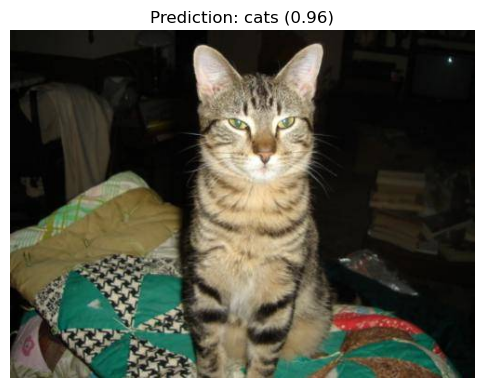

[{'label': 'cats', 'score': 0.9559813141822815},
 {'label': 'dogs', 'score': 0.04401864856481552}]

In [15]:
image_path = DATA_DIR + "/test/cats/cat.1070.jpg"
predict_image(image_path)

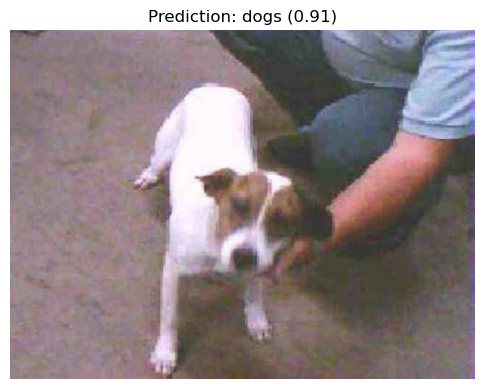

[{'label': 'dogs', 'score': 0.9082930684089661},
 {'label': 'cats', 'score': 0.09170696884393692}]

In [16]:
image_path = DATA_DIR + "/test/dogs/dog.1233.jpg"
predict_image(image_path)

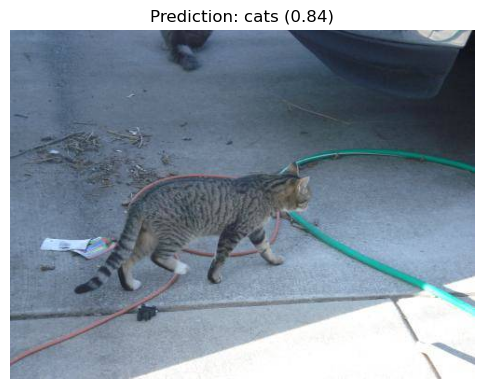

[{'label': 'cats', 'score': 0.8381505608558655},
 {'label': 'dogs', 'score': 0.16184943914413452}]

In [17]:
image_path = DATA_DIR + "/test/cats/cat.1080.jpg"
predict_image(image_path)

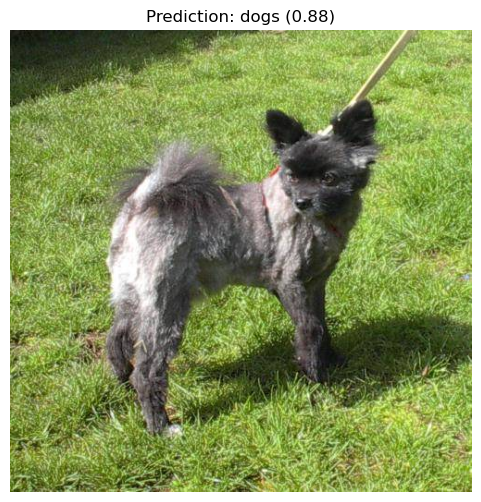

[{'label': 'dogs', 'score': 0.8836382627487183},
 {'label': 'cats', 'score': 0.11636176705360413}]

In [18]:
image_path = DATA_DIR + "/test/dogs/dog.1132.jpg"
predict_image(image_path)

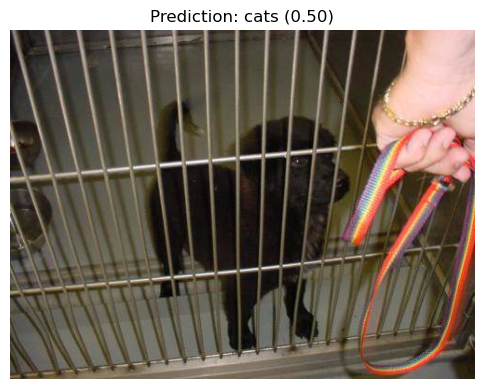

[{'label': 'cats', 'score': 0.5009765625},
 {'label': 'dogs', 'score': 0.4990234076976776}]

In [19]:
image_path = DATA_DIR + "/test/dogs/dog.1311.jpg"
predict_image(image_path)

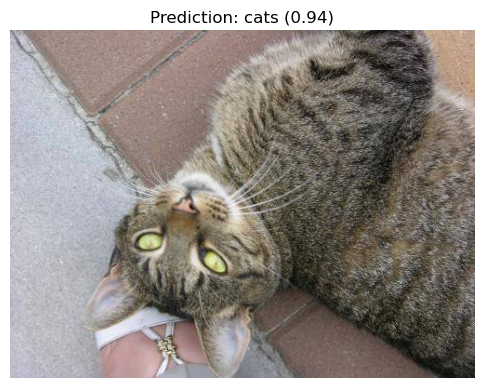

[{'label': 'cats', 'score': 0.9425067901611328},
 {'label': 'dogs', 'score': 0.05749328061938286}]

In [20]:
image_path = DATA_DIR + "/test/cats/cat.1338.jpg"
predict_image(image_path)

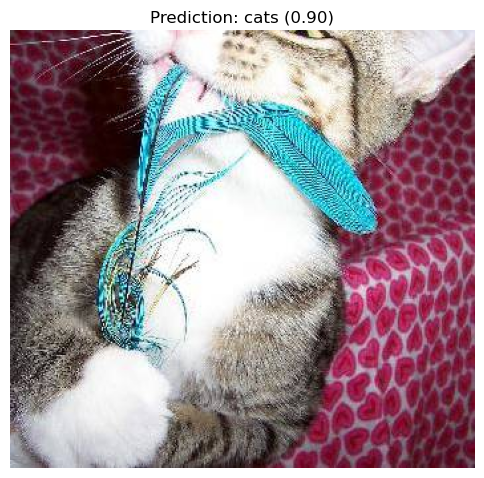

[{'label': 'cats', 'score': 0.897335946559906},
 {'label': 'dogs', 'score': 0.10266400873661041}]

In [21]:
image_path = DATA_DIR + "/test/cats/cat.1342.jpg"
predict_image(image_path)

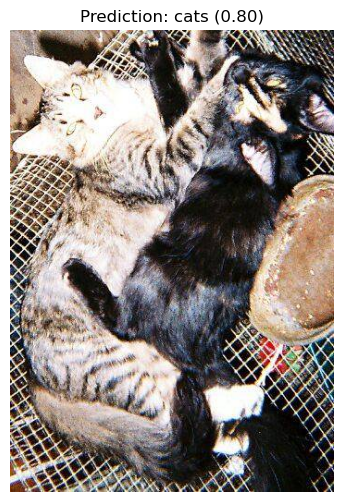

[{'label': 'cats', 'score': 0.8000679016113281},
 {'label': 'dogs', 'score': 0.19993211328983307}]

In [22]:
image_path = DATA_DIR + "/test/cats/cat.1048.jpg"
predict_image(image_path)

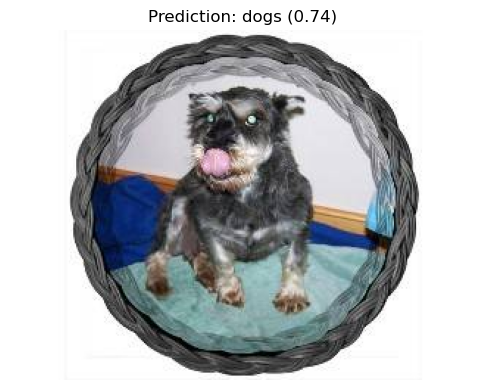

[{'label': 'dogs', 'score': 0.7446563243865967},
 {'label': 'cats', 'score': 0.2553436756134033}]

In [23]:
image_path = DATA_DIR + "/test/dogs/dog.1342.jpg"
predict_image(image_path)